In [1]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from vqvae2 import VQVAE, VQVAE2


/workspace/vqvae-2/vqvae2/vq.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
def load_model(checkpoint_path, model):
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    return model

def preprocess_image(image_path, image_size):
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0)
    return img_tensor

def postprocess_image(recon_tensor):
    recon_img = recon_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    recon_img = recon_img * 255
    recon_img = np.clip(recon_img, 0, 255).astype(np.uint8)
    return recon_img

/tmp/ipykernel_3481338/138385501.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location='cpu')


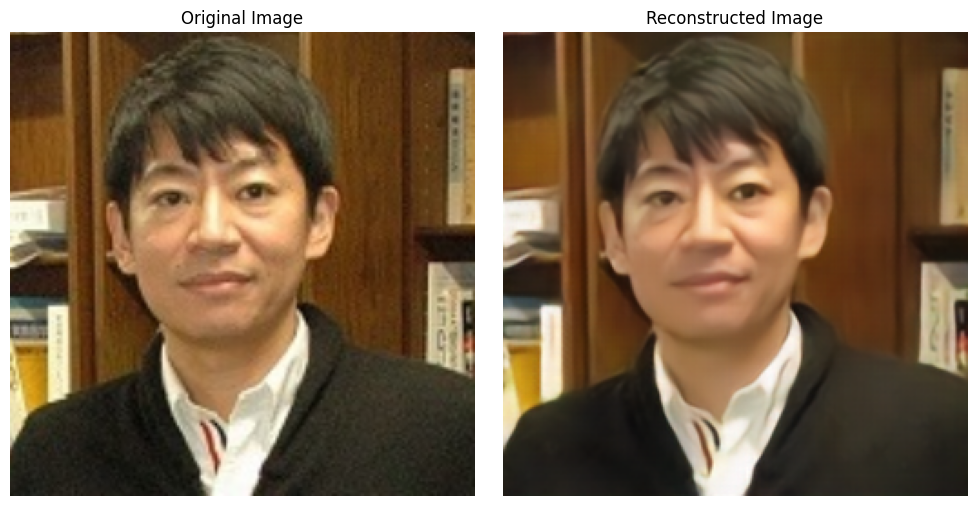

In [8]:
    # --- Configuration ---
checkpoint_path = "/workspace/exp/vqvae_2025-07-07_13-47-30/checkpoints/state_dict_final.pt"
image_path = "/workspace/vqvae-2/data/colo/hayashi-2.png"
image_size = (256, 256)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Build Model ---
config = {
    "in_dim": 3,
    "hidden_dim": 128,
    "codebook_dim": 64,
    "codebook_size": 512,
    "num_residual_layers": 2,
    "residual_dim": 64,
    "resample_factors": [2, 2, 2, 2]
}
model = VQVAE2.build_from_config(config)
model.to(device)

# --- Load Model ---
model = load_model(checkpoint_path, model)

# --- Preprocess Image ---
input_tensor = preprocess_image(image_path, image_size).to(device)

# --- Inference ---
with torch.no_grad():
    reconstruction, _, _, _ = model(input_tensor)

# --- Postprocess Image ---
original_img = Image.open(image_path).resize(image_size)
reconstructed_img_np = postprocess_image(reconstruction)
reconstructed_img = Image.fromarray(reconstructed_img_np)

# --- Display Results ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img)
plt.title("Reconstructed Image")
plt.axis('off')

plt.tight_layout()
plt.show()